In [ ]:

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm

from google.colab import drive

import warnings
import math
import numbers

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

# Load & Prepare the PhysioNet 2012 data

In [ ]:
# mount Google Drive
drive.mount('/content/drive')

# paths to PhysioNet 2012 data in Google Drive
google_drive_folder = '/content/drive/MyDrive/physionet2012/'
set_a_directory = f"{google_drive_folder}/set-a"
set_b_directory = f"{google_drive_folder}/set-b"
set_c_directory = f"{google_drive_folder}/set-c"
outcomes_a_file = f"{set_a_directory}/Outcomes-a.txt"
outcomes_b_file = f"{set_b_directory}/Outcomes-b.txt"
outcomes_c_file = f"{set_c_directory}/Outcomes-c.txt"

print("Set A Directory:", set_a_directory)
print("Set B Directory:", set_b_directory)
print("Set C Directory:", set_c_directory)
print("Outcomes A File:", outcomes_a_file)
print("Outcomes B File:", outcomes_b_file)
print("Outcomes C File:", outcomes_c_file)

Mounted at /content/drive
Set A Directory: /content/drive/MyDrive/physionet2012//set-a
Set B Directory: /content/drive/MyDrive/physionet2012//set-b
Set C Directory: /content/drive/MyDrive/physionet2012//set-c
Outcomes A File: /content/drive/MyDrive/physionet2012//set-a/Outcomes-a.txt
Outcomes B File: /content/drive/MyDrive/physionet2012//set-b/Outcomes-b.txt
Outcomes C File: /content/drive/MyDrive/physionet2012//set-c/Outcomes-c.txt


In [ ]:
outcomes_a = pd.read_csv(outcomes_a_file)
outcomes_b = pd.read_csv(outcomes_b_file)
outcomes_c = pd.read_csv(outcomes_c_file)

outcomes_a['set'] = 'a'
outcomes_b['set'] = 'b'
outcomes_c['set'] = 'c'

combined_outcomes = pd.concat([outcomes_a, outcomes_b, outcomes_c], ignore_index=True)

# filter out records with In-hospital_death == -1
filtered_outcomes = combined_outcomes[combined_outcomes['In-hospital_death'] != -1].reset_index(drop=True)
print("Number of records after filtering:", len(filtered_outcomes))

Number of records after filtering: 12000


In [ ]:
def parse_patient_file(file_path):
    df = pd.read_csv(file_path)

    static_features = {}
    dynamic_features = {}

    for index, row in df.iterrows():
        time_str = row['Time']
        param = row['Parameter']
        value = row['Value']

        # convert time to minutes
        if ':' in time_str:
            hours, minutes = map(int, time_str.split(':'))
            total_minutes = hours*60 + minutes
        else:
            try:
                total_minutes = float(time_str)
            except:
                total_minutes = 0

        if total_minutes == 0:
            static_features[param] = value
        else:
            if total_minutes not in dynamic_features:
                dynamic_features[total_minutes] = {}
            dynamic_features[total_minutes][param] = value

    if dynamic_features:
        dynamic_df = pd.DataFrame.from_dict(dynamic_features, orient='index').sort_index()
        dynamic_df.index.name = 'Time'
        dynamic_df.reset_index(inplace=True)
    else:
        dynamic_df = pd.DataFrame(columns=['Time'])

    # attach static features as columns
    for k,v in static_features.items():
        dynamic_df[k] = v

    return dynamic_df

In [ ]:
def load_all_patients(set_path, outcomes_df):
    patient_data = []
    labels = []

    patient_files = [f for f in os.listdir(set_path)
                     if f.endswith('.txt') and not f.startswith('Outcomes')]

    for pf in tqdm(patient_files, desc=f"Loading {set_path}"):
        try:
            record_id = int(pf.replace('.txt',''))
        except:
            continue
        file_path = os.path.join(set_path, pf)
        df = parse_patient_file(file_path)

        df['RecordID'] = record_id
        outcome = outcomes_df[outcomes_df['RecordID'] == record_id]
        if outcome.empty:
            continue
        label = outcome['In-hospital_death'].values[0]

        patient_data.append(df)
        labels.append(label)

    return patient_data, labels

In [ ]:
train_data, train_labels = load_all_patients(set_a_directory,
                                            filtered_outcomes[filtered_outcomes['set']=='a'])
val_data, val_labels = load_all_patients(set_b_directory,
                                        filtered_outcomes[filtered_outcomes['set']=='b'])

test_data, test_labels = load_all_patients( set_c_directory,
                                           filtered_outcomes[filtered_outcomes['set']=='c'])


print("\nNumber of train samples:", len(train_data))
print("Number of val samples:", len(val_data))
print("Number of test samples:", len(test_data))

Loading /content/drive/MyDrive/physionet2012//set-a: 100%|██████████| 4000/4000 [03:09<00:00, 21.15it/s]
Loading /content/drive/MyDrive/physionet2012//set-b: 100%|██████████| 4000/4000 [02:50<00:00, 23.44it/s]
Loading /content/drive/MyDrive/physionet2012//set-c: 100%|██████████| 4000/4000 [02:59<00:00, 22.23it/s]


Number of train samples: 4000
Number of val samples: 4000
Number of test samples: 4000


# Create Sequences (X, Mask, Delta) + Labels

In [ ]:
def create_sequences(patient_dfs, labels, dynamic_feats, max_time=201):
    """
    convert each patient's dataframe into (x, mask, delta) + label.
    we'll pad to max_time steps.
    returns dict of np.arrays: x, mask, delta, y.
    """
    X_list, M_list, D_list, y_list = [], [], [], []

    num_feats = len(dynamic_feats)

    for i, df in enumerate(tqdm(patient_dfs, desc='building sequences')):
        lab = labels[i]
        df = df.sort_values('Time').reset_index(drop=True)

        # times
        times = df['Time'].values.astype(float)

        # Check if 'times' is empty before proceeding
        if times.size == 0:
            warnings.warn(f"patient {i} has no time entries. skipping.")
            continue

        delta_times = np.diff(times, prepend=times[0])
        delta_times[delta_times < 0] = 0.0  # safety


        # construct dynamic array (T, D)
        # if a dynamic feature doesn't appear, it's just nan in that row.
        # get the common features
        common_features = list(set(dynamic_feats).intersection(df.columns))


        # use the common features to create the array
        arr = df[common_features].values.astype(float)  # shape (T, num_common_feats)
        T = arr.shape[0]

        # create mask
        mask_arr = ~np.isnan(arr)
        mask_arr = mask_arr.astype(float)

        # fill missing with 0 for now
        arr_filled = np.nan_to_num(arr, nan=0.0)

        # expand delta_times to shape (T, D)
        delta_expand = np.tile(delta_times.reshape(-1,1), (1, len(common_features))) # use len(common_features)

        # now pad/truncate to max_time
        seq_len = min(T, max_time)

        X_padded = np.zeros((max_time, len(common_features)), dtype=np.float32) # use len(common_features)
        M_padded = np.zeros((max_time, len(common_features)), dtype=np.float32) # use len(common_features)
        D_padded = np.zeros((max_time, len(common_features)), dtype=np.float32) # use len(common_features)

        X_padded[:seq_len] = arr_filled[:seq_len]
        M_padded[:seq_len] = mask_arr[:seq_len]
        D_padded[:seq_len] = delta_expand[:seq_len]

        X_list.append(X_padded)
        M_list.append(M_padded)
        D_list.append(D_padded)
        y_list.append(lab)

    # adjust the shape of the output arrays to match the number of common features
    max_num_features = max(x.shape[1] for x in X_list)  # get the max number of features
    X_array = np.zeros((len(X_list), max_time, max_num_features), dtype=np.float32)  # initialize with zeros
    M_array = np.zeros((len(X_list), max_time, max_num_features), dtype=np.float32)  # initialize with zeros
    D_array = np.zeros((len(X_list), max_time, max_num_features), dtype=np.float32)  # initialize with zeros

    for i, (x, m, d) in enumerate(zip(X_list, M_list, D_list)):
        num_features = x.shape[1]
        X_array[i, :, :num_features] = x
        M_array[i, :, :num_features] = m
        D_array[i, :, :num_features] = d

    y_array = np.array(y_list, dtype=np.float32)

    return {
        'X': X_array,
        'mask': M_array,
        'delta': D_array,
        'y': y_array
    }

In [ ]:
# identify static features (Physionet 2012)
static_features = ['Age', 'Gender', 'Height', 'ICUType', 'Weight']

# dynamic features are all columns except 'Time' and static features
dynamic_features = ['Albumin', 'ALP', 'ALT', 'AST', 'Bilirubin', 'BUN', 'Cholesterol',
            'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
            'HR', 'K', 'Lactate', 'Mg', 'MAP', 'MechVent', 'Na', 'NIDiasABP',
            'NIMAP', 'NISysABP', 'PaCO2', 'PaO2', 'pH', 'Platelets', 'RespRate',
            'SaO2', 'SysABP', 'Temp', 'TropI', 'TropT', 'Urine', 'WBC', 'Weight'
        ]


In [ ]:
train_seqs = create_sequences(train_data, train_labels, dynamic_features, max_time=201)
val_seqs   = create_sequences(val_data,   val_labels,   dynamic_features, max_time=201)
test_seqs = create_sequences(test_data, test_labels, dynamic_features, max_time=201)

print("Train X shape:", train_seqs['X'].shape)
print("Val   X shape:", val_seqs['X'].shape)
print("Unique train labels:", np.unique(train_seqs['y']))
print("Unique val   labels:", np.unique(val_seqs['y']))
print("Test   X shape:", test_seqs['X'].shape)
print("Unique test   labels:", np.unique(test_seqs['y']))


Building sequences:  10%|▉         | 398/4000 [00:00<00:03, 994.09it/s]<ipython-input-8-16003defa2b7>:22: UserWarning: Patient 419 has no time entries. Skipping.
  warnings.warn(f"Patient {i} has no time entries. Skipping.")
Building sequences:  31%|███       | 1229/4000 [00:01<00:02, 1037.02it/s]<ipython-input-8-16003defa2b7>:22: UserWarning: Patient 1243 has no time entries. Skipping.
  warnings.warn(f"Patient {i} has no time entries. Skipping.")
Building sequences:  68%|██████▊   | 2703/4000 [00:02<00:01, 1034.70it/s]<ipython-input-8-16003defa2b7>:22: UserWarning: Patient 2723 has no time entries. Skipping.
  warnings.warn(f"Patient {i} has no time entries. Skipping.")
Building sequences:  16%|█▌        | 629/4000 [00:00<00:03, 1063.80it/s]<ipython-input-8-16003defa2b7>:22: UserWarning: Patient 652 has no time entries. Skipping.
  warnings.warn(f"Patient {i} has no time entries. Skipping.")
Building sequences:  34%|███▍      | 1378/4000 [00:01<00:02, 1052.87it/s]<ipython-input-8-160

Train X shape: (3997, 201, 34)
Val   X shape: (3993, 201, 34)
Unique train labels: [0. 1.]
Unique val   labels: [0. 1.]
Test   X shape: (3998, 201, 34)
Unique test   labels: [0. 1.]


# Define Manual GRU-D Model (Vectorized for Batches)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class GRUD(nn.Module):
    def __init__(
        self,
        input_size, # dimensionality of the features (d)
        hidden_size, # dimensionality of the hidden state (h)
        output_size=1, # usually 1 for binary classification
        x_mean=None,
        dropout=0.0,
        dropout_type='mloss',
    ):
        """
        manual grud implementation.
        """
        super(GRUD, self).__init__()
        self.input_size = input_size   # number of features (d)
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout = dropout
        self.dropout_type = dropout_type

        # if no mean is provided, default to zeros
        if x_mean is None:
            self.register_buffer("x_mean", torch.zeros(input_size))
        else:
            self.register_buffer("x_mean", torch.tensor(x_mean, dtype=torch.float32))

        # define the "decay" linear layers
        # w_dg_x:  (d -> d),   w_dg_h: (d -> h).
        # this is how we compute gamma_x(t) and gamma_h(t) from delta_t.
        self.W_dg_x = nn.Linear(input_size, input_size, bias=True)
        self.W_dg_h = nn.Linear(input_size, hidden_size, bias=True)

        # gru gates: z, r, h_tilde
        # we keep the "m_t" gate terms as in che et al.
        self.w_xz = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.w_hz = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.w_mz = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_z  = nn.Parameter(torch.Tensor(hidden_size))

        self.w_xr = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.w_hr = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.w_mr = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_r  = nn.Parameter(torch.Tensor(hidden_size))

        self.w_xh = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.w_hh = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.w_mh = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_h  = nn.Parameter(torch.Tensor(hidden_size))

        # final classifier layer
        self.w_hy = nn.Parameter(torch.Tensor(hidden_size, output_size))
        self.b_y  = nn.Parameter(torch.Tensor(output_size))

        self.reset_parameters()

    def reset_parameters(self):
        # simple uniform initialization
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for p in self.parameters():
            nn.init.uniform_(p, -stdv, stdv)

    def forward(self, X, M, Delta):
        """
        X:     (batch_size, T, D)   - raw features
        M:     (batch_size, T, D)   - mask (1 if observed, 0 if missing)
        Delta: (batch_size, T, D)   - time since last observation for each feature
        Returns:
            (batch_size,) or (batch_size, 1) if output_size=1
        """
        batch_size, T, D = X.size()
        H = self.hidden_size

        # initialize hidden state and "previous" imputed x
        h = X.new_zeros(batch_size, H)      # shape (batch_size, H)
        x_hat = X.new_zeros(batch_size, D)  # shape (batch_size, D)

        # for dropout
        dropout_layer = nn.Dropout(self.dropout)

        for t in range(T):
            x_t = X[:, t, :]      # shape (batch_size, D)
            m_t = M[:, t, :]      # shape (batch_size, D)
            d_t = Delta[:, t, :]  # shape (batch_size, D)

            # compute gamma_x(t) and gamma_h(t)
            # gamma_x: (batch_size, D)
            # gamma_h: (batch_size, H)
            gamma_x_t = torch.exp(-F.relu(self.W_dg_x(d_t)))
            gamma_h_t = torch.exp(-F.relu(self.W_dg_h(d_t)))

            # update x_hat(t)
            # x_hat(t) = m_t * x_t  + (1-m_t)* [ gamma_x_t*x_hat(t-1) + (1-gamma_x_t)* x_mean ]
            x_hat = m_t * x_t + (1 - m_t) * (gamma_x_t * x_hat + (1 - gamma_x_t) * self.x_mean)

            # decay hidden state: h(t-1) -> gamma_h(t) * h(t-1)
            h = gamma_h_t * h

            # standard gru gating on the imputed input x_hat(t)
            # z gate
            z = torch.sigmoid(
                x_hat @ self.w_xz + h @ self.w_hz + m_t @ self.w_mz + self.b_z
            )

            # r gate
            r = torch.sigmoid(
                x_hat @ self.w_xr + h @ self.w_hr + m_t @ self.w_mr + self.b_r
            )

            # h tilde
            h_tilde = torch.tanh(
                x_hat @ self.w_xh + (r * h) @ self.w_hh + m_t @ self.w_mh + self.b_h
            )

            # apply dropout
            if self.dropout > 0:
                if self.dropout_type == 'mloss':
                    h_tilde = dropout_layer(h_tilde)
                elif self.dropout_type == 'Gal':
                    h = dropout_layer(h)

            # gru update
            h = (1 - z) * h + z * h_tilde

        # final output
        y_out = h @ self.w_hy + self.b_y  # (batch_size, output_size)
        y_out = torch.sigmoid(y_out)
        return y_out.squeeze(-1)  # shape (batch_size,) if output_size=1

# Create PyTorch Dataset & DataLoaders

In [ ]:
class PhysioNetDataset(Dataset):
    def __init__(self, seqs_dict):
        # seqs_dict has 'X', 'mask', 'delta', 'y'
        self.X = seqs_dict['X']  # shape (N, T, D)
        self.M = seqs_dict['mask']
        self.D = seqs_dict['delta']
        self.y = seqs_dict['y']

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return (
            self.X[idx],  # shape (T, D)
            self.M[idx],
            self.D[idx],
            self.y[idx],
        )

# create dataset objects
train_dataset = PhysioNetDataset(train_seqs)
val_dataset   = PhysioNetDataset(val_seqs)
test_dataset = PhysioNetDataset(test_seqs)
# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(len(train_loader), len(val_loader), len(test_loader))

125 125 125


# Train the Manual GRU-D Model

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_features = train_seqs['X'].shape[-1]
model = GRUD(
    input_size=n_features,
    hidden_size=32,
    output_size=1,
    x_mean=None,
    dropout=0.05,
    dropout_type='mloss',
).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
patience = 15
best_val_auc = 0.0
epochs_no_improve = 0

best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(1, epochs+1):
    model.train()
    train_losses = []
    train_preds = []
    train_truth = []

    for batch in train_loader:
        Xb, Mb, Db, yb = batch
        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(Xb, Mb, Db)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_preds.append(preds.detach().cpu().numpy())
        train_truth.append(yb.detach().cpu().numpy())

    train_preds = np.concatenate(train_preds)
    train_truth = np.concatenate(train_truth)
    train_loss  = np.mean(train_losses)
    train_auc   = roc_auc_score(train_truth, train_preds)

    model.eval()
    val_losses = []
    val_preds = []
    val_truth = []
    with torch.no_grad():
        for batch in val_loader:
            Xb, Mb, Db, yb = batch
            Xb = Xb.to(device)
            Mb = Mb.to(device)
            Db = Db.to(device)
            yb = yb.to(device)

            preds = model(Xb, Mb, Db)
            loss = criterion(preds, yb)
            val_losses.append(loss.item())

            val_preds.append(preds.cpu().numpy())
            val_truth.append(yb.cpu().numpy())

    val_preds = np.concatenate(val_preds)
    val_truth = np.concatenate(val_truth)
    val_loss  = np.mean(val_losses)
    val_auc   = roc_auc_score(val_truth, val_preds)

    print(f"Epoch [{epoch}/{epochs}]")
    print(f"  Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.3f}")
    print(f"  Val   Loss: {val_loss:.4f}   | Val   AUC: {val_auc:.3f}\n")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"early stopping triggered after {epoch} epochs.")
            model.load_state_dict(best_model_weights)
            break

model.load_state_dict(best_model_weights)
print(f"finished training. best val auc: {best_val_auc:.3f}")

Epoch [1/50]
  Train Loss: 0.4821 | Train AUC: 0.547
  Val   Loss: 0.4144   | Val   AUC: 0.531

Epoch [2/50]
  Train Loss: 0.3954 | Train AUC: 0.600
  Val   Loss: 0.4006   | Val   AUC: 0.603

Epoch [3/50]
  Train Loss: 0.3861 | Train AUC: 0.650
  Val   Loss: 0.3979   | Val   AUC: 0.619

Epoch [4/50]
  Train Loss: 0.3809 | Train AUC: 0.667
  Val   Loss: 0.3942   | Val   AUC: 0.643

Epoch [5/50]
  Train Loss: 0.3729 | Train AUC: 0.695
  Val   Loss: 0.3948   | Val   AUC: 0.645

Epoch [6/50]
  Train Loss: 0.3672 | Train AUC: 0.715
  Val   Loss: 0.3943   | Val   AUC: 0.645

Epoch [7/50]
  Train Loss: 0.3633 | Train AUC: 0.729
  Val   Loss: 0.3912   | Val   AUC: 0.659

Epoch [8/50]
  Train Loss: 0.3599 | Train AUC: 0.742
  Val   Loss: 0.3917   | Val   AUC: 0.660

Epoch [9/50]
  Train Loss: 0.3525 | Train AUC: 0.762
  Val   Loss: 0.3904   | Val   AUC: 0.666

Epoch [10/50]
  Train Loss: 0.3518 | Train AUC: 0.756
  Val   Loss: 0.3903   | Val   AUC: 0.668

Epoch [11/50]
  Train Loss: 0.3491 | Tr

# Inference / Probability Outputs

In [ ]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [ ]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for batch in val_loader:
        Xb, Mb, Db, yb = batch
        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        preds = model(Xb, Mb, Db)
        all_probs.append(preds.cpu().numpy())
        all_labels.append(yb.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

print("Validation AUC:", roc_auc_score(all_labels, all_probs))

Validation AUC: 0.6902256605325383


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

probs = all_probs
labels = all_labels

thresholds = np.linspace(0.0, 1.0, 101)
best_thresh = 0.0
best_f1 = 0.0

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1_t = f1_score(labels, preds_t)
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thresh = t

print(f"Best threshold for F1 is {best_thresh:.2f} with F1={best_f1:.3f}")

Best threshold for F1 is 0.14 with F1=0.333


In [ ]:
# -----------------------------------------------------
#  Evaluate final performance on Set C (test_loader)
# -----------------------------------------------------
import numpy as np
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score, roc_curve, auc)

model.eval()
all_test_probs = []
all_test_labels = []
with torch.no_grad():
    for batch in test_loader:
        Xb, Mb, Db, yb = batch
        Xb = Xb.to(device)
        Mb = Mb.to(device)
        Db = Db.to(device)
        preds = model(Xb, Mb, Db)
        all_test_probs.append(preds.cpu().numpy())
        all_test_labels.append(yb.numpy())

all_test_probs = np.concatenate(all_test_probs)
all_test_labels = np.concatenate(all_test_labels)
test_auc = roc_auc_score(all_test_labels, all_test_probs)
print("=== Final Results on Set C ===")
print("Test (Set C) AUC:", test_auc)

preds_c = (all_test_probs >= best_thresh).astype(int)
acc_c = accuracy_score(all_test_labels, preds_c)
auprc_c = average_precision_score(all_test_labels, all_test_probs)
prec_c = precision_score(all_test_labels, preds_c)
rec_c  = recall_score(all_test_labels, preds_c)
f1_c   = f1_score(all_test_labels, preds_c)

print(f"Accuracy = {acc_c:.4f}")
print(f"AUPRC    = {auprc_c:.4f}")
print(f"Precision= {prec_c:.4f}")
print(f"Recall   = {rec_c:.4f}")
print(f"F1       = {f1_c:.4f}")



=== Final Results on Set C ===
Test (Set C) AUC: 0.6869656241469896
Accuracy = 0.6691
AUPRC    = 0.2734
Precision= 0.2376
Recall   = 0.5709
F1       = 0.3355


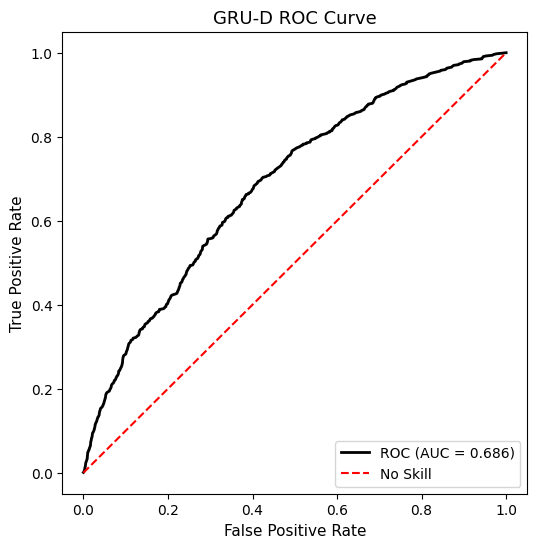

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


fpr_c, tpr_c, _ = roc_curve(all_test_labels, all_test_probs)
roc_auc_c = auc(fpr_c, tpr_c)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 6))
sns.lineplot(x=fpr_c, y=tpr_c, color='black', linewidth=2,
             label=f'ROC (AUC = {roc_auc_c:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='No Skill')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('GRU-D ROC Curve', fontsize=13)
plt.legend(loc='lower right')
plt.show()


<ipython-input-19-ee5016cea718>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_c.groupby("bin")


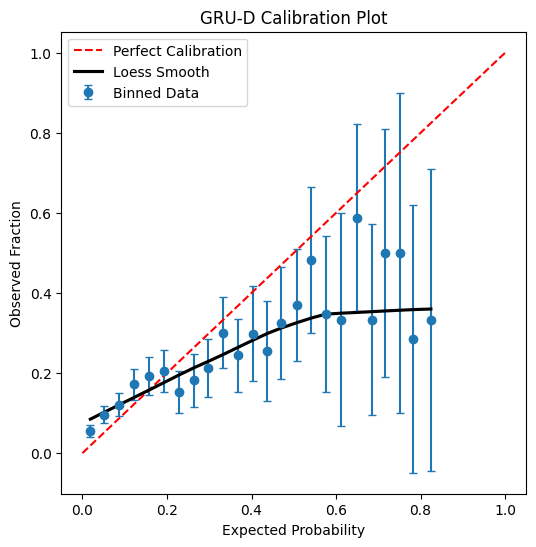

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_c = pd.DataFrame({"prob": all_test_probs, "label": all_test_labels})
num_cuts = 24

df_c["bin"] = pd.cut(df_c["prob"], bins=num_cuts, include_lowest=True)

grouped_c = (
    df_c.groupby("bin")
    .agg(
        observed=("label", "mean"),
        expected=("prob", "mean"),
        n=("label", "count")
    )
    .reset_index()
)
grouped_c["se"] = np.sqrt(grouped_c["observed"] * (1 - grouped_c["observed"]) / grouped_c["n"])

plt.figure(figsize=(6, 6))
plt.errorbar(
    x=grouped_c["expected"],
    y=grouped_c["observed"],
    yerr=1.96 * grouped_c["se"],
    fmt="o",
    capsize=3,
    label="Binned Data"
)
plt.plot([0, 1], [0, 1], "r--", label="Perfect Calibration")

sns.regplot(
    x="expected",
    y="observed",
    data=grouped_c,
    scatter=False,
    lowess=True,
    label="Loess Smooth",
    color="black"
)

plt.xlabel("Expected Probability")
plt.ylabel("Observed Fraction")
plt.title("GRU-D Calibration Plot")
plt.legend(loc="best")
plt.show()